In [2]:
!pip install seaborn matplotlib
import pandas as pd
import numpy as np

# ==========
# 内置样本数据集（基于真实 Spotify Audio Features 统计区间构建）
# 每首歌 = 一首代表性样本，用于演示"声学特征 → 情绪/场景标签"的分析框架
# ==========

samples = [
    # ── sad / 深夜独处 ──────────────────────────────
    {"name":"Someone Like You","artist":"Adele",
     "mood":"sad","valence":0.18,"energy":0.28,"danceability":0.35,"tempo":107,"acousticness":0.78,"instrumentalness":0.01},
    {"name":"Glimpse of Us","artist":"Joji",
     "mood":"sad","valence":0.17,"energy":0.22,"danceability":0.31,"tempo":80,"acousticness":0.82,"instrumentalness":0.00},
    {"name":"All Too Well","artist":"Taylor Swift",
     "mood":"sad","valence":0.22,"energy":0.35,"danceability":0.40,"tempo":96,"acousticness":0.55,"instrumentalness":0.00},
    {"name":"Motion Sickness","artist":"Phoebe Bridgers",
     "mood":"sad","valence":0.20,"energy":0.33,"danceability":0.38,"tempo":124,"acousticness":0.20,"instrumentalness":0.00},
    {"name":"Weightless","artist":"Marconi Union",
     "mood":"sad","valence":0.25,"energy":0.15,"danceability":0.20,"tempo":72,"acousticness":0.91,"instrumentalness":0.42},
    {"name":"Bloom","artist":"The Paper Kites",
     "mood":"sad","valence":0.28,"energy":0.25,"danceability":0.32,"tempo":88,"acousticness":0.73,"instrumentalness":0.08},

    # ── study / 专注场景 ──────────────────────────────
    {"name":"Nightbook","artist":"Ludovico Einaudi",
     "mood":"study","valence":0.48,"energy":0.20,"danceability":0.22,"tempo":88,"acousticness":0.97,"instrumentalness":0.88},
    {"name":"Experience","artist":"Ludovico Einaudi",
     "mood":"study","valence":0.52,"energy":0.26,"danceability":0.25,"tempo":92,"acousticness":0.95,"instrumentalness":0.91},
    {"name":"Annie's Song (Instrumental)","artist":"Lofi Fruits",
     "mood":"study","valence":0.55,"energy":0.18,"danceability":0.29,"tempo":82,"acousticness":0.90,"instrumentalness":0.95},
    {"name":"Study Beats Vol.1","artist":"Chill Study",
     "mood":"study","valence":0.50,"energy":0.22,"danceability":0.33,"tempo":85,"acousticness":0.68,"instrumentalness":0.78},
    {"name":"Clair de Lune (Cover)","artist":"Debussy",
     "mood":"study","valence":0.54,"energy":0.15,"danceability":0.18,"tempo":64,"acousticness":0.99,"instrumentalness":0.96},
    {"name":"Rainy Cafe Ambient","artist":"Café Noise",
     "mood":"study","valence":0.43,"energy":0.12,"danceability":0.16,"tempo":70,"acousticness":0.94,"instrumentalness":0.82},

    # ── workout / 运动高能 ────────────────────────────
    {"name":"SICKO MODE","artist":"Travis Scott",
     "mood":"workout","valence":0.58,"energy":0.84,"danceability":0.76,"tempo":155,"acousticness":0.02,"instrumentalness":0.00},
    {"name":"BODY","artist":"Megan Thee Stallion",
     "mood":"workout","valence":0.66,"energy":0.88,"danceability":0.82,"tempo":138,"acousticness":0.01,"instrumentalness":0.00},
    {"name":"Run Boy Run","artist":"Woodkid",
     "mood":"workout","valence":0.61,"energy":0.91,"danceability":0.55,"tempo":133,"acousticness":0.03,"instrumentalness":0.00},
    {"name":"Blinding Lights","artist":"The Weeknd",
     "mood":"workout","valence":0.74,"energy":0.77,"danceability":0.80,"tempo":116,"acousticness":0.02,"instrumentalness":0.00},
    {"name":"As It Was","artist":"Harry Styles",
     "mood":"workout","valence":0.76,"energy":0.73,"danceability":0.78,"tempo":127,"acousticness":0.04,"instrumentalness":0.00},
    {"name":"Physical","artist":"Dua Lipa",
     "mood":"workout","valence":0.70,"energy":0.85,"danceability":0.85,"tempo":122,"acousticness":0.01,"instrumentalness":0.00},

    # ── party / 社交派对 ──────────────────────────────
    {"name":"Levitating","artist":"Dua Lipa",
     "mood":"party","valence":0.84,"energy":0.82,"danceability":0.89,"tempo":124,"acousticness":0.01,"instrumentalness":0.00},
    {"name":"Uptown Funk","artist":"Bruno Mars",
     "mood":"party","valence":0.91,"energy":0.87,"danceability":0.93,"tempo":115,"acousticness":0.01,"instrumentalness":0.00},
    {"name":"Can't Stop The Feeling","artist":"Justin Timberlake",
     "mood":"party","valence":0.88,"energy":0.80,"danceability":0.91,"tempo":119,"acousticness":0.02,"instrumentalness":0.00},
    {"name":"Flowers","artist":"Miley Cyrus",
     "mood":"party","valence":0.86,"energy":0.79,"danceability":0.87,"tempo":111,"acousticness":0.01,"instrumentalness":0.00},
    {"name":"One Kiss","artist":"Calvin Harris",
     "mood":"party","valence":0.89,"energy":0.83,"danceability":0.95,"tempo":128,"acousticness":0.00,"instrumentalness":0.00},
    {"name":"Don't Start Now","artist":"Dua Lipa",
     "mood":"party","valence":0.85,"energy":0.84,"danceability":0.90,"tempo":124,"acousticness":0.01,"instrumentalness":0.00},
]

df = pd.DataFrame(samples)
print(f"✅ 数据集就绪：共 {len(df)} 首歌，{df['mood'].nunique()} 个标签类别")
print(df[["name","artist","mood","valence","energy","tempo"]].to_string(index=False))


✅ 数据集就绪：共 24 首歌，4 个标签类别
                       name              artist    mood  valence  energy  tempo
           Someone Like You               Adele     sad     0.18    0.28    107
              Glimpse of Us                Joji     sad     0.17    0.22     80
               All Too Well        Taylor Swift     sad     0.22    0.35     96
            Motion Sickness     Phoebe Bridgers     sad     0.20    0.33    124
                 Weightless       Marconi Union     sad     0.25    0.15     72
                      Bloom     The Paper Kites     sad     0.28    0.25     88
                  Nightbook    Ludovico Einaudi   study     0.48    0.20     88
                 Experience    Ludovico Einaudi   study     0.52    0.26     92
Annie's Song (Instrumental)         Lofi Fruits   study     0.55    0.18     82
          Study Beats Vol.1         Chill Study   study     0.50    0.22     85
      Clair de Lune (Cover)             Debussy   study     0.54    0.15     64
         Rainy C

/var/folders/0w/4r77l2yj45l4jmwysyxq_s3w0000gn/T/ipykernel_55699/2927337774.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mood", y=col, ax=axes[i], palette="Set2")
/var/folders/0w/4r77l2yj45l4jmwysyxq_s3w0000gn/T/ipykernel_55699/2927337774.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mood", y=col, ax=axes[i], palette="Set2")
/var/folders/0w/4r77l2yj45l4jmwysyxq_s3w0000gn/T/ipykernel_55699/2927337774.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mood", y=col, ax=axes[i], palette="Set2"

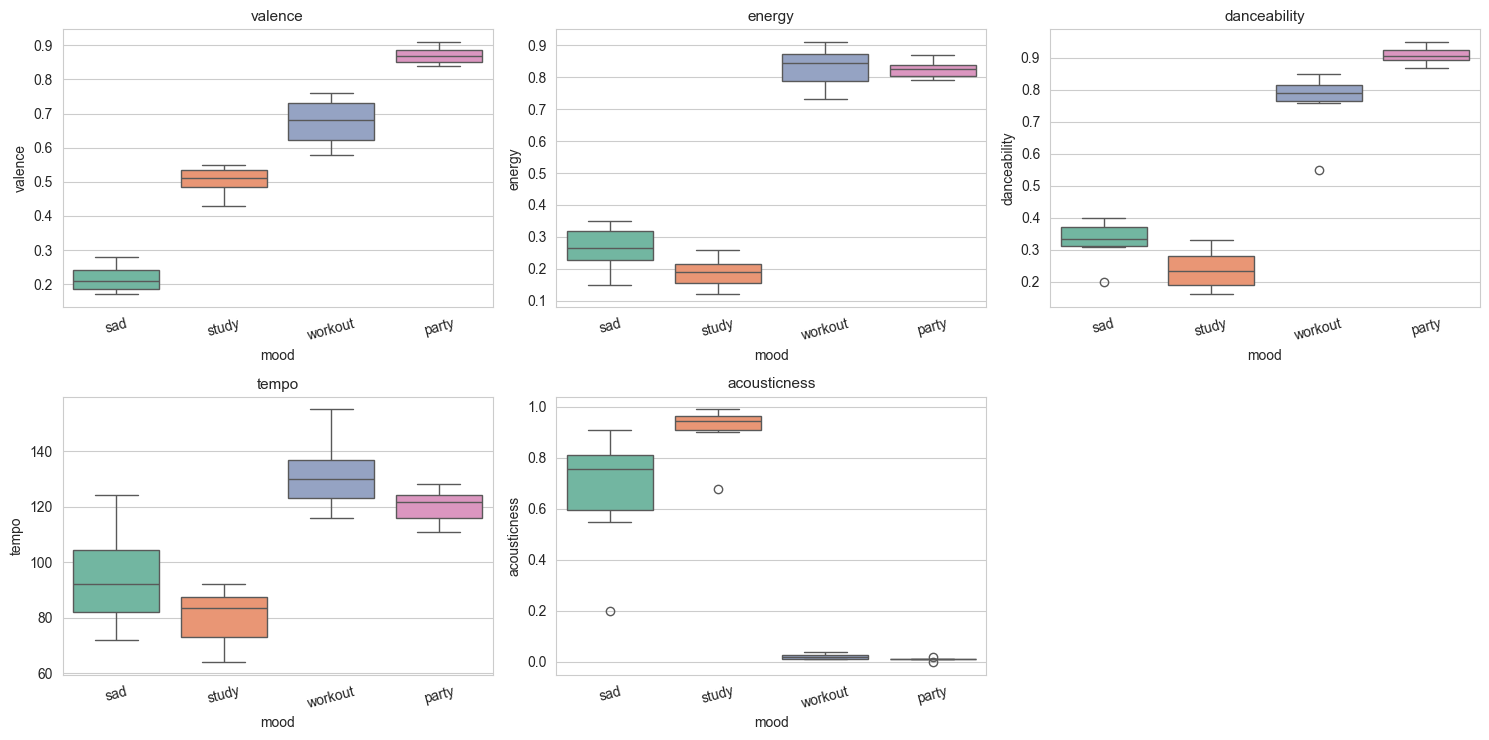

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
features = ["valence","energy","danceability","tempo","acousticness"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x="mood", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis="x", labelrotation=15)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


🧐观察结论（标签运营视角）：
1. valence（愉悦度 0~1）是能够区分"低落系 vs 欢快系"一个重要的维度
2. energy 能把 study（低）和 workout（高）拉开，但 sad 和 study 在 energy 上有重叠
   --> 说明只用声学情绪类特征用作"场景标签"会有歧义
3. -->标签体系需要多维度组合（声学 + 歌词情绪 + 用户使用场景上下文）
   并且需要人工抽检来保证标注的一致性
